# Customer Sales & Trend Analysis

This project analyzes retail transaction data to identify sales trends, top products, and customer behavior using Python (Pandas).

## 1. Import Libraries and Load Data

In [2]:
import pandas as pd

df = pd.read_csv("../data/online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Data Understanding

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [8]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


## 3. Data Cleaning

### 3.1 Handling Duplicate Rows

In [12]:
df.duplicated().sum()

np.int64(34335)

### Handling Duplicate Rows

The dataset contains duplicate records, which can lead to incorrect analysis.  
We will remove duplicate rows to ensure data accuracy.

In [23]:
df=df.drop_duplicates()

In [5]:
df.duplicated().sum()

np.int64(0)

After removing duplicates, the dataset is now free of repeated records and ready for further cleaning.

### 3.2 Handling Missing Values

Some columns contain missing values. We will handle them to ensure clean and reliable analysis.

In [29]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

We will remove rows with missing Customer IDs because they are not useful for customer-based analysis.

In [24]:
df=df.dropna(subset=["Customer ID"])

In [32]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

### 3.3 Removing Invalid Values

### 3.3 Removing Invalid Values

To understand invalid values in the dataset, we examined different combinations of Quantity and Price.

Before handling missing values, a small number of rows had negative prices. However, these rows also had missing Customer IDs and were removed during the missing value cleaning step.

After cleaning missing values, no rows with negative prices remain.

Further analysis shows that the remaining invalid values are rows with negative Quantity, which represent returned or canceled orders.

Since this project focuses on sales performance, these return transactions are removed to ensure accurate analysis.

In [25]:
# Count invalid cases after cleaning
negative_quantity = df[df["Quantity"] < 0].shape[0]
negative_price = df[df["Price"] < 0].shape[0]

negative_quantity, negative_price

(18390, 0)

In [26]:
# Remove return/cancelled transactions
df = df[df["Quantity"] > 0]

This ensures that the analysis reflects only actual sales transactions.

### 3.4 Fixing Data Types

Some columns in the dataset have incorrect data types that may affect analysis.

- `InvoiceDate` is stored as a string and needs to be converted to datetime format for time-based analysis.
- `Customer ID` is stored as a float, which is not appropriate for identifiers.

After converting these columns, the dataset becomes properly structured for accurate and efficient analysis.

After conversion, the dataset is better structured for analysis, especially for time-based insights.

In [27]:
# Convert data types
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Customer ID"] = df["Customer ID"].astype(int)
print("Updated Data Types:")

# Verify changes
df.info()

Updated Data Types:
<class 'pandas.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  str           
 1   StockCode    779495 non-null  str           
 2   Description  779495 non-null  str           
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[us]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  int64         
 7   Country      779495 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 53.5 MB


### 3.5 Creating TotalPrice Column

To analyze revenue, we create a new column called `TotalPrice`.

This column represents the total value of each transaction and is calculated by multiplying the quantity of items purchased by the unit price.

This feature is essential for analyzing sales trends, top products, and customer spending.

In [28]:
# Create TotalPrice column
df["TotalPrice"] = df["Quantity"] * df["Price"]

# Verify calculation
df[["Quantity", "Price", "TotalPrice"]].head()

,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


## 4. Data Analysis and Visualization

### 4.1 Sales Over Time (Trend Analysis)

To understand business performance, we analyze how sales change over time.

This helps answer key business questions:
- When are sales highest?
- Is the business growing month over month?

We will group the data by month and calculate total sales for each period.

In [29]:
# Extract Month from InvoiceDate
df['Month']=df['InvoiceDate'].dt.to_period('M')

In [30]:
# Group by Month and calculate total sales
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

# Preview result
monthly_sales.head()

Month
2009-12    683504.010
2010-01    555802.672
2010-02    504558.956
2010-03    696978.471
2010-04    591982.002
Freq: M, Name: TotalPrice, dtype: float64

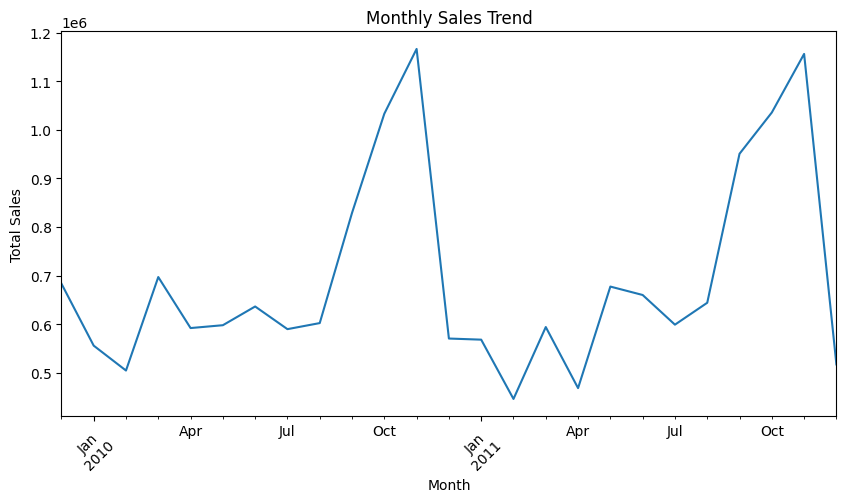

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

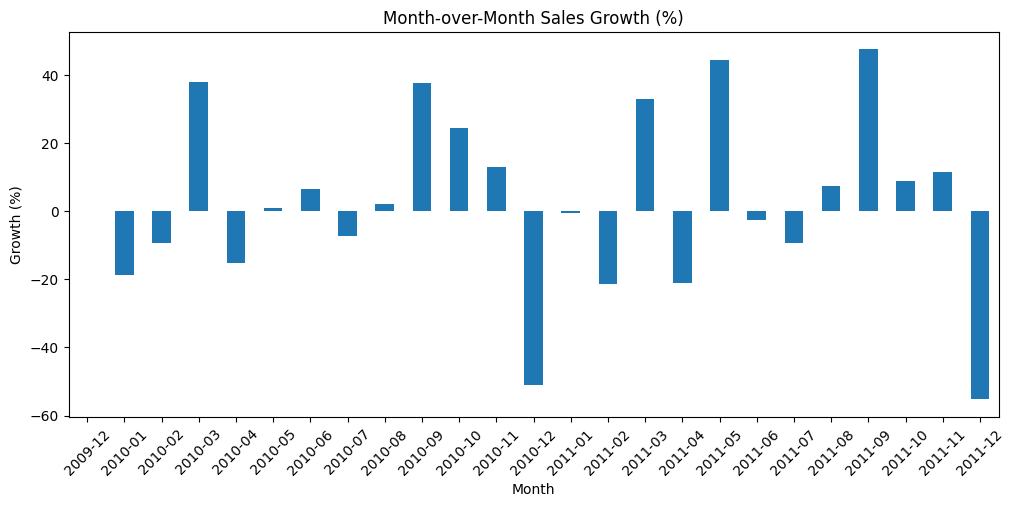

In [17]:
# Month-over-month percentage change
monthly_growth = monthly_sales.pct_change() * 100  # convert to %
monthly_growth.plot(kind="bar", figsize=(12,5))
plt.title("Month-over-Month Sales Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.show()

In [31]:
# Find the month with highest sales
monthly_sales.sort_values(ascending=False).head(1)

Month
2010-11    1166460.022
Freq: M, Name: TotalPrice, dtype: float64

In [32]:
# Month-over-month growth
monthly_sales.pct_change().head

<bound method NDFrame.head of Month
2009-12         NaN
2010-01   -0.186833
2010-02   -0.092198
2010-03    0.381362
2010-04   -0.150645
2010-05    0.009884
2010-06    0.064462
2010-07   -0.073283
2010-08    0.021176
2010-09    0.376586
2010-10    0.246194
2010-11    0.129074
2010-12   -0.510980
2011-01   -0.004070
2011-02   -0.214779
2011-03    0.331768
2011-04   -0.211600
2011-05    0.446183
2011-06   -0.025554
2011-07   -0.092544
2011-08    0.075277
2011-09    0.476110
2011-10    0.089358
2011-11    0.116414
2011-12   -0.552667
Freq: M, Name: TotalPrice, dtype: float64>

### Key Insights

- Sales are highest in: November 2010  
- Sales trend: Fluctuating with a repeating seasonal pattern  

From the trend, we observe that:

- The business shows seasonal fluctuations rather than consistent growth.
- Sales tend to increase toward the end of the year and decrease at the beginning of the year.
- A similar pattern is observed across both years, indicating recurring customer behavior.

### Conclusion

Sales peak during November–December, indicating strong seasonal performance likely driven by holiday demand.

The overall trend suggests that the business is stable, with predictable seasonal variations rather than steady growth.

### 4.2 Top selling products 


To understand which products perform best, we analyze the total quantity sold for each product.

This helps answer the key business question:
- Which products sell the most?

By identifying top-selling products, the business can focus on stocking high-demand items and optimizing inventory.

In [33]:
top_products = df.groupby(["StockCode","Description"])['Quantity'].sum()
top_products = top_products.sort_values(ascending=False).head(10) 
top_products 


StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
85123A     WHITE HANGING HEART T-LIGHT HOLDER     91757
23843      PAPER CRAFT , LITTLE BIRDIE            80995
84879      ASSORTED COLOUR BIRD ORNAMENT          78234
23166      MEDIUM CERAMIC TOP STORAGE JAR         77916
85099B     JUMBO BAG RED RETROSPOT                74224
17003      BROCADE RING PURSE                     70082
21977      PACK OF 60 PINK PAISLEY CAKE CASES     54592
84991      60 TEATIME FAIRY CAKE CASES            52828
21212      PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

In [13]:
top_products=top_products.reset_index()

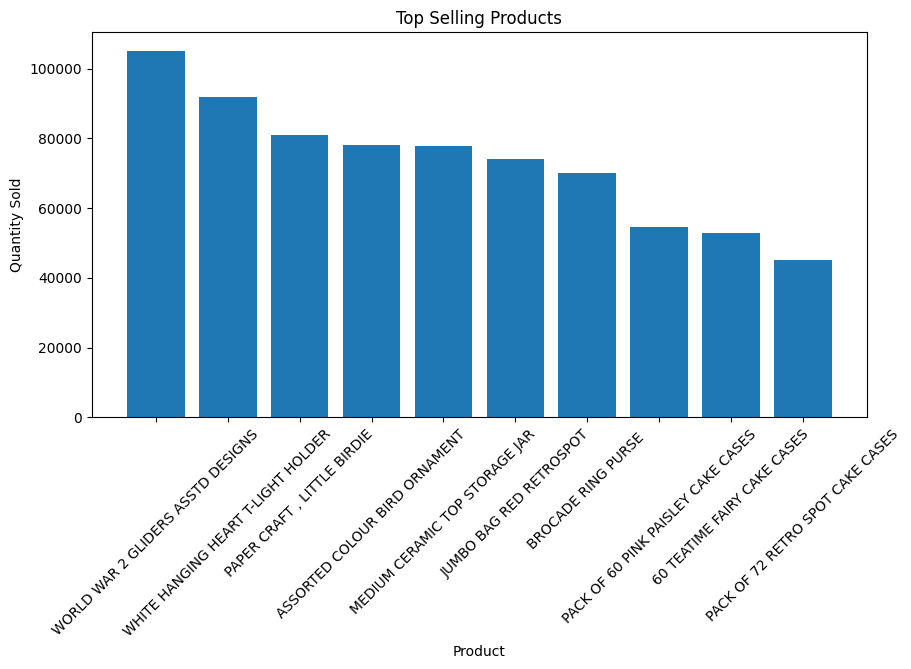

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top_products["Description"], top_products["Quantity"])

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout

plt.show()

### Key Insights

- The top-selling product is: WORLD WAR 2 GLIDERS ASSTD DESIGNS  
- The top 10 products contribute significantly to total sales volume.

From the analysis, we observe that:

- A small number of products dominate sales.
- Products such as decorative items and gift-related items appear frequently among top sellers.
- Demand is concentrated on specific popular items.

### Conclusion

The business should prioritize stocking and promoting top-selling products.

Focusing on high-demand items can improve revenue and inventory efficiency.

### 4.3 Top Customers

To identify the most valuable customers, we analyze total spending per customer.

This helps answer:
  - Who spends the most?
  - Which customers contribute the most revenue?

By identifying top customers, the business can focus on retention and maximize revenue from high-value clients.

In [24]:
top_customers=df.groupby("Customer ID", as_index=False)["TotalPrice"].sum()
top_customers=top_customers.sort_values("TotalPrice",ascending = False).head(10)
top_customers

,Customer ID,TotalPrice
5695,18102,580987.04
2279,14646,528602.52
1791,14156,313437.62
2541,14911,291420.81
5053,17450,244784.25
1332,13694,195640.69
5112,17511,172132.87
4064,16446,168472.50
4298,16684,147142.77
68,12415,144458.37


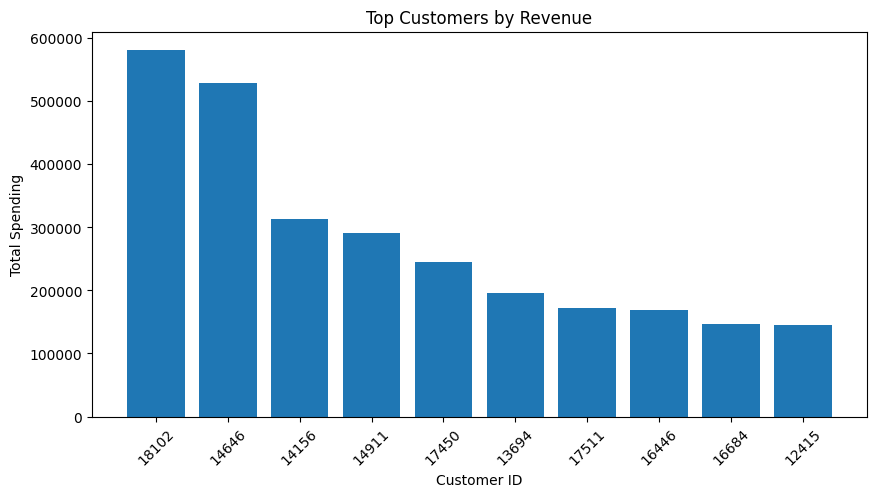

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(top_customers["Customer ID"].astype(str), top_customers["TotalPrice"])

plt.title("Top Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)

plt.show()

### Key Insights
-The highest spending customer is: Customer ID 18102
-The top 10 customers contribute a significant portion of total revenue.

From the analysis, we observe that:

-A small number of customers generate a large share of total sales.
-Customer spending is highly concentrated among top buyers.
-These high-value customers are critical to business success.
### Conclusion
Although customer identities are not available, the data shows that a small group of customers drives most of the revenue.

The business should:

-Track these high-value customers more closely
-Implement loyalty and retention strategies
-Personalize offers to increase repeat purchases

### 4.4 Sales by Country

To identify which countries generate the most revenue we analyse total spending per country.
This helps answer:
-Which region performs best?

In [37]:
top_regions=df.groupby("Country", as_index=False)["TotalPrice"].sum()
top_regions=top_regions.sort_values("TotalPrice",ascending=False).head(10)
top_regions

,Country,TotalPrice
38,United Kingdom,1.438923e+07
10,EIRE,6.165705e+05
24,Netherlands,5.540381e+05
14,Germany,4.250197e+05
13,France,3.487690e+05
0,Australia,1.692835e+05
32,Spain,1.083325e+05
34,Switzerland,1.000619e+05
33,Sweden,9.151582e+04
9,Denmark,6.858069e+04


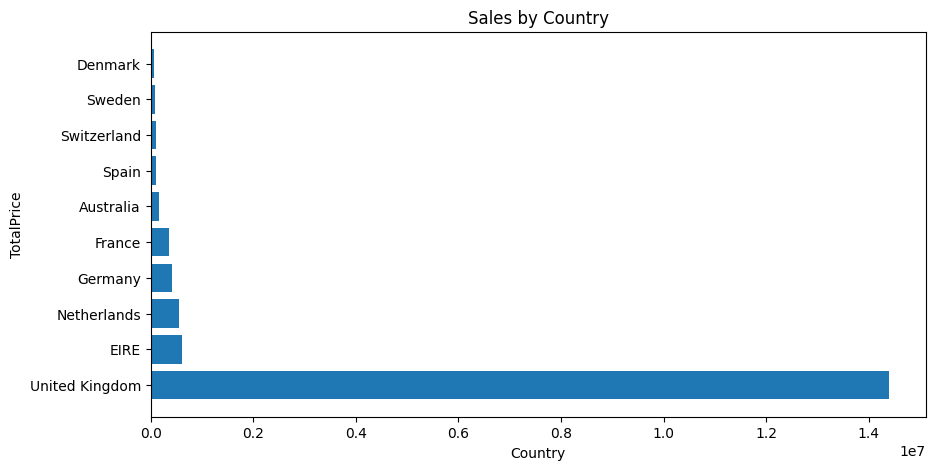

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(top_regions["Country"].astype(str), top_regions["TotalPrice"])

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("TotalPrice")

plt.show()


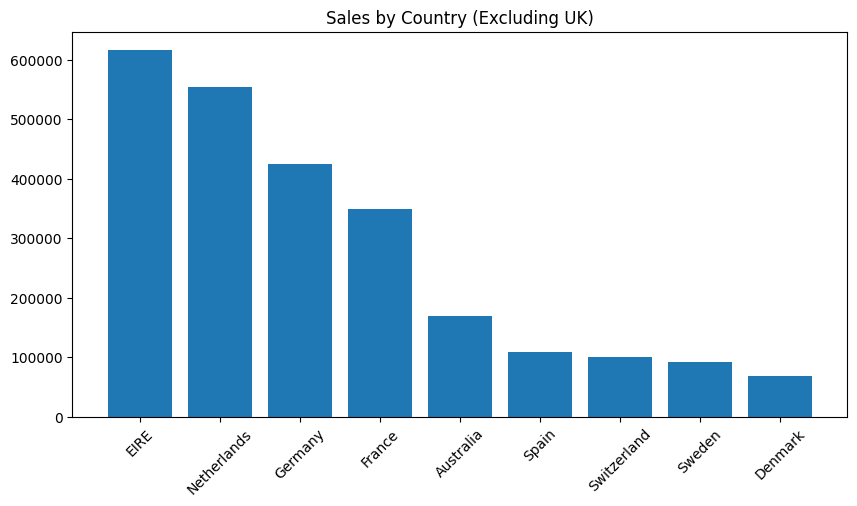

In [55]:
top_regions_no_uk = top_regions[top_regions["Country"] != "United Kingdom"]

plt.figure(figsize=(10,5))
plt.bar(top_regions_no_uk["Country"], top_regions_no_uk["TotalPrice"])

plt.xticks(rotation=45)
plt.title("Sales by Country (Excluding UK)")
plt.show()

### Key Insights

- The highest performing country is: United Kingdom  
- The United Kingdom contributes a significantly larger share of total revenue compared to all other countries.

From the analysis, we observe that:

- Sales are heavily concentrated in a single dominant market (United Kingdom).
- Other countries contribute relatively small portions of total revenue.
- European countries such as Netherlands, Germany, and France follow, but at a much lower scale.

### Conclusion

The business is highly dependent on the United Kingdom market.

This indicates:
- Strong market dominance in the UK
- Limited diversification across other regions

### Recommendation

To improve long-term growth and reduce risk, the business should:

- Expand marketing efforts in other countries  
- Strengthen presence in high-potential regions like Europe  
- Reduce dependency on a single market

## 5. Final Insights & Recommendations

### 🔍 Key Findings

From the analysis of sales data, several important patterns emerge:

#### 1. Sales Trends
- Sales show a **fluctuating pattern with clear seasonality**.
- Revenue peaks during **November**, indicating strong end-of-year demand.
- This suggests that sales are influenced by **seasonal factors such as holidays**.

#### 2. Product Performance
- A small number of products generate the majority of sales.
- The top-selling product is:
  - **WORLD WAR 2 GLIDERS ASSTD DESIGNS**
- Many top products are **decorative and gift-related items**, indicating customer preferences.

#### 3. Customer Behavior
- Revenue is highly concentrated among a **small group of top customers**.
- The highest spending customer contributes significantly more than others.
- This indicates the presence of **high-value customers (VIP customers)**.

#### 4. Geographic Performance
- The **United Kingdom dominates sales** by a large margin.
- Other countries such as Netherlands, Germany, and France contribute much less.
- This shows **low geographic diversification**.

---

### 📈 Business Interpretation

From these findings, we can conclude:

- The business experiences **seasonal demand**, especially during the holiday period.
- Sales depend heavily on:
  - A few **popular products**
  - A small group of **high-value customers**
  - A single dominant market (**United Kingdom**)

---

### 🚀 Recommendations

To improve business performance and reduce risk, the company should:

#### 🛍️ 1. Optimize Inventory
- Increase stock levels before peak months (e.g., November–December)
- Focus on high-demand products

#### 🎯 2. Strengthen Customer Strategy
- Identify and retain top customers through:
  - Loyalty programs
  - Personalized offers
- Encourage repeat purchases

#### 🌍 3. Expand International Presence
- Invest in marketing in other countries
- Target high-potential regions such as Europe
- Reduce reliance on the UK market

#### 📊 4. Data-Driven Decision Making
- Continuously monitor sales trends
- Use data to forecast demand and plan inventory

---

### 🧠 Final Conclusion

The business is currently **strong but highly concentrated** in key areas.

Future growth depends on:
- Expanding into new markets  
- Diversifying product demand  
- Retaining high-value customers  

By leveraging these insights, the company can achieve **sustainable and scalable growth**.